<a href="https://colab.research.google.com/github/vamsiyadagiri24-dot/Stroke-prediction-agent/blob/main/Driver_Monitoring_Phase1_Phase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Driver Activity Monitoring — Phase 1 (ML Model) + Phase 2 (AI Agent)

**Dataset:** `full_data_carla.csv` — sensor data generated from the CARLA driving simulator.

**Columns:**
- `accelX`, `accelY`, `accelZ` — accelerometer readings
- `gyroX`, `gyroY`, `gyroZ` — gyroscope readings
- `class` — target label: identifies the **driver** (`apo`, `berk`, `gonca`, `hurcan`, `mehdi`, `onder`, `selin`)

Each class represents a distinct driver's sensor-motion signature, so this notebook builds a model that
classifies **who is driving / which driver's behavioral pattern** a given sensor reading matches — the driver
activity/behaviour classification task for this assignment.

**Structure:**
- **Phase 1** — Load, clean, train & compare ML models (Random Forest, XGBoost, SVM, KNN, MLP), evaluate with
  Accuracy / Precision / Recall / F1 / Confusion Matrix, and save the best model.
- **Phase 2** — Build the `DriverMonitoringAgent` that uses the saved model to classify new readings, raise
  alerts, and maintain a monitoring report — all in the same runtime, no re-uploading of model files needed.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
# PHASE 1 — Machine Learning Model

## Step 1: Upload the dataset
Run this cell and select `full_data_carla.csv` from your computer.

In [ ]:
from google.colab import files
uploaded = files.upload()  # select full_data_carla.csv

Saving full_data_carla.csv to full_data_carla.csv


## Step 2: Load & explore the data

In [ ]:
import pandas as pd

df = pd.read_csv("full_data_carla.csv")
print(df.shape)
df.head()

(99358, 8)


,Unnamed: 0,accelX,accelY,accelZ,class,gyroX,gyroY,gyroZ
0,0,-0.244069,8.094744e-02,9.807350,apo,0.0,0.0,0.0
1,1,-0.206027,-9.387732e-07,9.807837,apo,0.0,0.0,0.0
2,2,-0.226992,-3.950313e-02,9.807553,apo,0.0,0.0,0.0
3,3,-0.225045,4.047326e-02,9.807437,apo,0.0,0.0,0.0
4,4,-0.226992,-3.950313e-02,9.807553,apo,0.0,0.0,0.0


In [ ]:
df.info()
print("\nMissing values:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99358 entries, 0 to 99357
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  99358 non-null  int64  
 1   accelX      99358 non-null  float64
 2   accelY      99358 non-null  float64
 3   accelZ      99358 non-null  float64
 4   class       99358 non-null  object 
 5   gyroX       99358 non-null  float64
 6   gyroY       99358 non-null  float64
 7   gyroZ       99358 non-null  float64
dtypes: float64(6), int64(1), object(1)
memory usage: 6.1+ MB

Missing values:
 Unnamed: 0    0
accelX        0
accelY        0
accelZ        0
class         0
gyroX         0
gyroY         0
gyroZ         0
dtype: int64


In [ ]:
target_col = "class"
print(df[target_col].value_counts())

class
selin     18982
onder     15708
apo       13738
berk      13192
gonca     12904
hurcan    12614
mehdi     12220
Name: count, dtype: int64


In [ ]:
# Drop the unnamed index column - it's just a row number, not a feature
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

feature_cols = ["accelX", "accelY", "accelZ", "gyroX", "gyroY", "gyroZ"]
df[feature_cols].describe()

,accelX,accelY,accelZ,gyroX,gyroY,gyroZ
count,99358.000000,99358.000000,99358.000000,99358.000000,99358.000000,99358.000000
mean,0.320035,-1.757734,9.610763,-0.008304,0.074616,-4.617131
std,3.290683,5.056490,1.750842,7.164488,7.313780,16.063510
min,-99.900000,-99.900000,-99.900000,-99.900000,-99.900000,-99.900000
25%,-1.307834,-1.910047,9.650203,-0.693553,-0.504339,-3.200509
50%,1.255837,-0.051751,9.790435,-0.000113,0.000000,-0.005528
75%,2.216757,0.066170,9.808281,0.687116,0.505699,0.021218
max,99.900000,99.900000,99.900000,99.900000,99.900000,99.900000


## Step 3: Clean outliers & preprocess
The sensor columns contain a small number of `±99.9` sentinel/error values (sensor glitches). We remove those rows, then encode labels, scale features, and split into train/test sets.

In [ ]:
# Remove sentinel/error readings (±99.9 indicates a sensor fault, not a real reading)
mask_valid = (df[feature_cols].abs() < 99.9).all(axis=1)
print(f"Dropping {(~mask_valid).sum()} rows with sensor error values out of {len(df)}")
df = df[mask_valid].reset_index(drop=True)

df = df.dropna()
print("Final shape after cleaning:", df.shape)

Dropping 286 rows with sensor error values out of 99358
Final shape after cleaning: (99072, 7)


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

X = df[feature_cols]
y = df[target_col]

le = LabelEncoder()
y_enc = le.fit_transform(y)
print("Class mapping:", dict(zip(le.classes_, range(len(le.classes_)))))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)
print(X_train.shape, X_test.shape)

Class mapping: {'apo': 0, 'berk': 1, 'gonca': 2, 'hurcan': 3, 'mehdi': 4, 'onder': 5, 'selin': 6}
(79257, 6) (19815, 6)


## Step 4: Train multiple models
Random Forest, XGBoost, SVM, KNN, and MLP.

In [ ]:
!pip install -q xgboost

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(eval_metric="mlogloss", random_state=42),
    "SVM": SVC(kernel="rbf", random_state=42, probability=True),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "MLP": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42),
}

results = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    results[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1}
    trained_models[name] = model
    print(f"--- {name} ---")
    print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

--- Random Forest ---
              precision    recall  f1-score   support

         apo       0.70      0.67      0.68      2722
        berk       0.68      0.65      0.66      2638
       gonca       0.70      0.69      0.70      2569
      hurcan       0.70      0.64      0.66      2521
       mehdi       0.68      0.64      0.66      2426
       onder       0.70      0.70      0.70      3142
       selin       0.73      0.84      0.78      3797

    accuracy                           0.70     19815
   macro avg       0.70      0.69      0.69     19815
weighted avg       0.70      0.70      0.70     19815

--- XGBoost ---
              precision    recall  f1-score   support

         apo       0.48      0.41      0.44      2722
        berk       0.47      0.37      0.41      2638
       gonca       0.48      0.47      0.47      2569
      hurcan       0.46      0.37      0.41      2521
       mehdi       0.44      0.40      0.42      2426
       onder       0.43      0.45      0

## Step 5: Compare models & visualize the confusion matrix

               Accuracy  Precision    Recall        F1
Random Forest  0.698612   0.697471  0.698612  0.696941
KNN            0.519152   0.520300  0.519152  0.518637
XGBoost        0.477063   0.472475  0.477063  0.469264
MLP            0.337472   0.321472  0.337472  0.315260
SVM            0.279132   0.307774  0.279132  0.227277


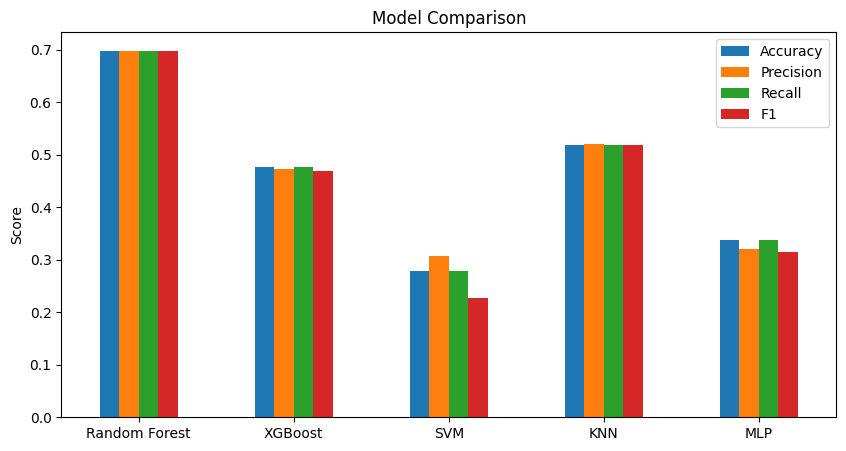

Best model: Random Forest


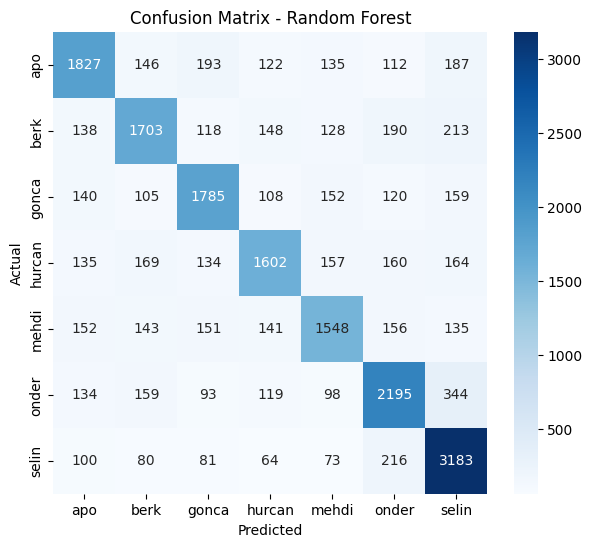

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

results_df = pd.DataFrame(results).T
print(results_df.sort_values("F1", ascending=False))

results_df.plot(kind="bar", figsize=(10, 5), title="Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

best_model_name = results_df["F1"].idxmax()
best_model = trained_models[best_model_name]
print("Best model:", best_model_name)

y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=le.classes_, yticklabels=le.classes_, cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

## Step 6 (Optional Extension): LSTM model
Treats consecutive rows as a short time-window sequence per reading. Optional — skip if not required.

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

def make_sequences(X, y, window=10):
    Xs, ys = [], []
    for i in range(len(X) - window):
        Xs.append(X[i:i+window])
        ys.append(y[i+window])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = make_sequences(X_scaled, y_enc, window=10)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42
)

n_classes = len(le.classes_)
lstm_model = Sequential([
    LSTM(64, input_shape=(X_train_s.shape[1], X_train_s.shape[2])),
    Dense(32, activation="relu"),
    Dense(n_classes, activation="softmax")
])
lstm_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
lstm_model.fit(X_train_s, y_train_s, epochs=15, batch_size=32, validation_split=0.1)

## Step 7: Save the best model
These artifacts feed directly into Phase 2 below (same notebook, no re-upload needed) and are also what you'll upload to GitHub for the Streamlit deployment.

In [ ]:
import joblib

joblib.dump(best_model, "driver_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(le, "label_encoder.pkl")
joblib.dump(feature_cols, "feature_columns.pkl")

from google.colab import files
files.download("driver_model.pkl")
files.download("scaler.pkl")
files.download("label_encoder.pkl")
files.download("feature_columns.pkl")

print("Saved and ready for Phase 2:", best_model_name)

---
# PHASE 2 — AI Driver Monitoring Agent

This section reuses `best_model`, `scaler`, `le`, and `feature_cols` from Phase 1 directly (since we're in the same notebook/runtime). If you're running Phase 2 standalone in a fresh runtime, just re-run the `joblib.load(...)` lines with the downloaded `.pkl` files.

## Step 1: Define the Driver Monitoring Agent

In [ ]:
import joblib
from datetime import datetime

class DriverMonitoringAgent:
    def __init__(self, model, scaler, encoder, feature_cols):
        self.model = model
        self.scaler = scaler
        self.encoder = encoder
        self.feature_cols = feature_cols
        self.report_log = []

    def predict(self, sensor_row: dict):
        X = pd.DataFrame([sensor_row])[self.feature_cols]
        X_scaled = self.scaler.transform(X)
        pred = self.model.predict(X_scaled)[0]
        label = self.encoder.inverse_transform([pred])[0]

        proba = None
        if hasattr(self.model, "predict_proba"):
            proba = float(max(self.model.predict_proba(X_scaled)[0]))

        alert = self._generate_alert(label, proba)
        entry = {
            "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            "predicted_driver": label,
            "confidence": round(proba, 3) if proba is not None else "N/A",
            "alert": alert,
        }
        self.report_log.append(entry)
        return entry

    def _generate_alert(self, label, proba):
        # Low-confidence prediction -> flag as an unrecognized / anomalous driving pattern
        if proba is not None and proba < 0.5:
            return f"WARNING: Unrecognized/uncertain driving pattern (closest match: {label}, confidence {proba:.2f})"
        return f"Recognized driving pattern for driver: {label}"

    def get_report(self):
        return pd.DataFrame(self.report_log)

    def save_report(self, path="monitoring_report.csv"):
        self.get_report().to_csv(path, index=False)
        print(f"Report saved to {path}")

    @classmethod
    def from_files(cls, model_path, scaler_path, encoder_path, features_path):
        return cls(
            joblib.load(model_path),
            joblib.load(scaler_path),
            joblib.load(encoder_path),
            joblib.load(features_path),
        )

## Step 2: Initialize the agent using the Phase 1 model

In [ ]:
# Using the objects already in memory from Phase 1
agent = DriverMonitoringAgent(best_model, scaler, le, feature_cols)

# --- OR, if running fresh in a new runtime, uncomment and use the saved files instead:
# agent = DriverMonitoringAgent.from_files(
#     "driver_model.pkl", "scaler.pkl", "label_encoder.pkl", "feature_columns.pkl"
# )

print("Agent ready. Expecting features:", agent.feature_cols)

## Step 3: Test the agent on real sensor readings from the dataset

In [ ]:
# Sample a few real rows (with their true label) to see the agent in action
sample_df = df.sample(5, random_state=1)

for _, row in sample_df.iterrows():
    sensor_reading = row[feature_cols].to_dict()
    result = agent.predict(sensor_reading)
    result["true_driver"] = row[target_col]
    print(result)

## Step 4: View and export the monitoring report

In [ ]:
report_df = agent.get_report()
report_df

In [ ]:
agent.save_report("monitoring_report.csv")

from google.colab import files
files.download("monitoring_report.csv")

## Step 5: Next step — Deploy as a Streamlit app

Package this same agent logic into an `app.py` Streamlit file, then deploy it via [Streamlit Community Cloud](https://share.streamlit.io):
1. Push `app.py`, `requirements.txt`, and the 4 `.pkl` files from Step 7 (Phase 1) to a GitHub repo.
2. On share.streamlit.io, click **New app**, select the repo, set the main file to `app.py`, and deploy.
3. You'll get a public link like `https://your-app-name.streamlit.app`.

---
# PHASE 3 — Deploy the Agent as a Streamlit App (inside Colab, via ngrok)

This runs the actual Streamlit web app **directly from Colab** and exposes it with a public URL using `pyngrok` — no GitHub or Streamlit Cloud account needed.

**You'll need a free ngrok auth token:**
1. Sign up at [ngrok.com](https://dashboard.ngrok.com/signup) (free).
2. Copy your auth token from [dashboard.ngrok.com/get-started/your-authtoken](https://dashboard.ngrok.com/get-started/your-authtoken).
3. Paste it into Step 2 below.

## Step 1: Install Streamlit and pyngrok

In [ ]:
!pip install -q streamlit pyngrok

## Step 2: Write the Streamlit app to disk\nThis writes `app.py` using the same agent logic from Phase 2, with a driver-identification UI (manual sensor input + batch CSV monitoring) and a downloadable report.

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
from datetime import datetime

st.set_page_config(page_title="Driver Activity Monitoring Agent", page_icon="\U0001F697", layout="wide")

# ---------------------------------------------------------------------------
# Load model artifacts (must be in the same folder as app.py)
# ---------------------------------------------------------------------------
@st.cache_resource
def load_artifacts():
    model = joblib.load("driver_model.pkl")
    scaler = joblib.load("scaler.pkl")
    encoder = joblib.load("label_encoder.pkl")
    feature_cols = joblib.load("feature_columns.pkl")
    return model, scaler, encoder, feature_cols

model, scaler, encoder, feature_cols = load_artifacts()

CONFIDENCE_THRESHOLD = 0.5


def predict_row(row: dict):
    X = pd.DataFrame([row])[feature_cols]
    X_scaled = scaler.transform(X)
    pred = model.predict(X_scaled)[0]
    label = encoder.inverse_transform([pred])[0]

    proba = None
    if hasattr(model, "predict_proba"):
        proba = float(max(model.predict_proba(X_scaled)[0]))

    if proba is not None and proba < CONFIDENCE_THRESHOLD:
        alert = f"\u26A0\uFE0F ALERT: Unrecognized/uncertain driving pattern (closest match: {label}, confidence {proba:.2f})"
    else:
        alert = f"\u2705 Recognized driving pattern for driver: {label}"

    return {
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "predicted_driver": label,
        "confidence": round(proba, 3) if proba is not None else "N/A",
        "alert": alert,
    }


# ---------------------------------------------------------------------------
# Session state for the monitoring report/history
# ---------------------------------------------------------------------------
if "report_log" not in st.session_state:
    st.session_state.report_log = []

st.title("\U0001F697 Driver Activity Monitoring Agent")
st.caption("Phase 2 - ML-powered driver identification and monitoring, from CARLA simulator sensor data")

tab1, tab2 = st.tabs(["\U0001F522 Manual Sensor Input", "\U0001F4C1 Batch CSV Monitoring"])

# ---------------------------------------------------------------------------
# Tab 1: Manual input
# ---------------------------------------------------------------------------
with tab1:
    st.subheader("Enter live sensor readings")

    cols = st.columns(3)
    row = {}
    for i, feat in enumerate(feature_cols):
        with cols[i % 3]:
            row[feat] = st.number_input(feat, value=0.0, format="%.4f", key=f"manual_{feat}")

    if st.button("Analyze Reading", type="primary"):
        result = predict_row(row)
        st.session_state.report_log.append(result)

        if "ALERT" in result["alert"]:
            st.error(result["alert"])
        else:
            st.success(result["alert"])

        st.write(f"**Predicted driver:** {result['predicted_driver']}  |  "
                  f"**Confidence:** {result['confidence']}")

# ---------------------------------------------------------------------------
# Tab 2: Batch CSV
# ---------------------------------------------------------------------------
with tab2:
    st.subheader("Upload a CSV of sensor readings for batch monitoring")
    st.caption(f"Required columns: {', '.join(feature_cols)}")
    uploaded = st.file_uploader("Upload CSV", type=["csv"])

    if uploaded is not None:
        batch_df = pd.read_csv(uploaded)
        missing = [c for c in feature_cols if c not in batch_df.columns]
        if missing:
            st.error(f"Uploaded file is missing required columns: {missing}")
        else:
            results = []
            for _, r in batch_df.iterrows():
                res = predict_row(r[feature_cols].to_dict())
                results.append(res)

            batch_results_df = pd.DataFrame(results)
            st.session_state.report_log.extend(results)

            st.dataframe(batch_results_df, use_container_width=True)

            n_alerts = batch_results_df["alert"].str.contains("ALERT").sum()
            st.metric("Rows flagged as uncertain/anomalous", n_alerts)

# ---------------------------------------------------------------------------
# Monitoring report / history (sidebar)
# ---------------------------------------------------------------------------
st.sidebar.header("\U0001F4CB Monitoring Report")

if st.session_state.report_log:
    report_df = pd.DataFrame(st.session_state.report_log)
    st.sidebar.dataframe(report_df.tail(20), use_container_width=True)

    csv = report_df.to_csv(index=False).encode("utf-8")
    st.sidebar.download_button("Download Full Report (CSV)", csv, "monitoring_report.csv", "text/csv")

    if st.sidebar.button("Clear Report"):
        st.session_state.report_log = []
        st.rerun()
else:
    st.sidebar.info("No readings analyzed yet.")

## Step 3: Make sure the model files are in this Colab session\nIf you're continuing straight from Phase 1 above in the same runtime, the files already exist. If you're in a fresh runtime, upload the 4 `.pkl` files you downloaded earlier.

In [ ]:
import os

required_files = ["driver_model.pkl", "scaler.pkl", "label_encoder.pkl", "feature_columns.pkl"]
missing = [f for f in required_files if not os.path.exists(f)]

if missing:
    print("Missing files, please upload them:", missing)
    from google.colab import files
    files.upload()
else:
    print("All model files found. Ready to launch.")

## Step 4: Set your ngrok auth token

In [ ]:
from pyngrok import ngrok

NGROK_AUTH_TOKEN = "3GX2pLoue3QesnEQj8Hq3iEZiLJ_3hAoxQhpcMPGmbggdFav8"  # <-- replace with your token
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

## Step 5: Launch Streamlit and open the public tunnel\nThis starts the Streamlit server in the background, then creates a public ngrok URL pointing to it. Click the printed link to open your live app.

In [ ]:
import subprocess
import time
from pyngrok import ngrok

# Kill any previous streamlit/ngrok sessions in this runtime
ngrok.kill()
get_ipython().system_raw("pkill -f streamlit || true")
time.sleep(2)

# Launch streamlit in the background on port 8501
get_ipython().system_raw("streamlit run app.py --server.port 8501 --server.headless true &")
time.sleep(5)

# Open a public tunnel to port 8501
public_url = ngrok.connect(8501)
print("Your Streamlit app is live at:", public_url)

## Step 6: Stop the app (run when you're done)\nNgrok free-tier tunnels also expire automatically after a few hours of inactivity — re-run Step 5 any time to relaunch and get a fresh link.

In [ ]:
from pyngrok import ngrok

ngrok.kill()
get_ipython().system_raw("pkill -f streamlit || true")
print("Streamlit app and ngrok tunnel stopped.")